# Part 1

The goal in part 1 is to create a baseline. We'll be using a CNN model — specifically ResNet-50 — because it's a well-established architecture pretrained on ImageNet, so it already knows how to extract meaningful visual features without prior training on Flickr8k. 

We'll be running every image through ResNet-50 once, recording its 2,048-dim output (feature extraction), then doing KNN search over those vectors. 

The KNN takes a query (test) image, finds the most visually similar image inside the training dataset, and outputs one of its captions — which becomes the predicted caption.

When we then compute corpus-level BLEU-1 to BLEU-4 on the test dataset, this will establish our baseline.

What we did:
1. `75% train / 12.5% val / 12.5% split`
2. Built the `ResNet50` extractor, without including the fully-connected layer at the top of the network and using global average pooling to make a 2D tensor that we can use for a KNN search. 
3. Define the helper `load_image` to resize and preprocess images per ResNet-50 expectations.
4. Extract the 2048-dimensional feature vector for every training image and save to cache for straightforward reloading when we come back.
5. Do the same for the test images. 
6. L2-normalize all feature vectors for both train and test so that the magnitude of each vector is the same (1.0), so that we can now use just direction, the only thing that varies, to represent visual content. 
7. Apply KNN to the normalized training features.
8. Define the helper `retrieve_caption`, which returns a caption from the nearest training image (this contains the name of the training image from which it stole the caption, and the caption it stole). But first map each training image name to its five captions. 
9. Map each test image name to its five captions. Run `retrieve_caption` on the full test set. Tokenize each test image's 5 test captions, as well as the predicted caption too. 
10. Compute corpus-level BLEU-1 through BLEU-4 on the test set.
11. Visualize a sample of test images, reference and its prediction. 

Import all the libraries and tools needed below.

In [1]:
import os
import certifi
os.environ['SSL_CERT_FILE'] = certifi.where()

import re
import random
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
# import sys
# !{sys.executable} -m pip install nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import tensorflow as tf
from keras.applications import ResNet50
from keras.applications.resnet50 import preprocess_input
import nltk

nltk.download('punkt', quiet = True)

random.seed(42)
np.random.seed(42)

Set the paths to the dataset. The `archive/` folder is expected to sit alongside this notebook.

In [2]:
ARCHIVE_DIR  = os.path.join(os.getcwd(), 'archive')
CAPTIONS_CSV = os.path.join(ARCHIVE_DIR, 'captions.txt')
IMAGES_DIR   = os.path.join(ARCHIVE_DIR, 'Images')
CACHE_DIR    = os.path.join(os.getcwd(), 'cache')

os.makedirs(CACHE_DIR, exist_ok = True)

### 1)

Load the captions file and reproduce the same train/val/test split used in the EDA (75% / 12.5% / 12.5%, seed 42). Splitting at the image level ensures all five captions for a given image stay in the same partition — no caption leaks across splits.

In [3]:
df = pd.read_csv(CAPTIONS_CSV)
df.columns = df.columns.str.strip()   # strip white space in front of 'image'

# tokenize and lowercase
def tokenize(text):
    return re.findall(r'[a-z]+', text.lower())

df['tokens'] = df['caption'].apply(tokenize)

# ensure reproducibility
all_images = sorted(df['image'].unique())
random.seed(42)
random.shuffle(all_images)

# train/val/test split
n       = len(all_images)
n_train = int(0.75  * n)
n_val   = int(0.125 * n)

train_imgs = set(all_images[:n_train])
val_imgs   = set(all_images[n_train : n_train + n_val])
test_imgs  = set(all_images[n_train + n_val:])

train_list = sorted(train_imgs)
test_list  = sorted(test_imgs)

print('Train images :', len(train_list))
print('Val images   :', len(val_imgs))
print('Test images  :', len(test_list))

Train images : 6068
Val images   : 1011
Test images  : 1012


### 2)

Build the ResNet-50 feature extractor. `include_top = False` drops the final classification layers, and `pooling = 'avg'` applies global average pooling so each image maps to a single 2,048-dimensional vector regardless of its original spatial size.

Reasoning:
- https://medium.com/@deepvisionkararhaider/resnet-50-explained-step-by-step-the-easiest-guide-to-deep-residual-networks-7616f4f45046

In [4]:
encoder = ResNet50(
    weights      = 'imagenet', # load pre-trained weights
    include_top  = False, # don't include the fully-connected layer at the top of the network
    pooling      = 'avg' # global average pooling to make 2D tensor used in KNN search
)
encoder.trainable = False

print('Output shape per image:', encoder.output_shape)

2026-06-04 21:20:29.309172: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-06-04 21:20:29.309247: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-04 21:20:29.309260: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-06-04 21:20:29.309295: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-04 21:20:29.309317: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Output shape per image: (None, 2048)


### 3)

Define a helper that loads one image from disk, resizes it to 224×224 (the size ResNet-50 was trained on), converts it to a NumPy array, and runs `preprocess_input` — which applies the same channel-wise mean subtraction used during ImageNet training.

In [ ]:
def load_image(filename):
    path  = os.path.join(IMAGES_DIR, filename)
    # load image as python imaging library object
    # force to rgb just in case
    # resize to 224x224 bc that's the shape ResNet-50 expects
    img   = Image.open(path).convert('RGB').resize((224, 224))
    arr   = np.array(img, dtype = 'float32') # convert to numpy array
    arr   = np.expand_dims(arr, axis = 0)   # (1, 224, 224, 3); add batch dim
    return preprocess_input(arr) # preprocessing per ResNet-50 expectations

### 4)

Extract a 2,048-dimensional feature vector for every training image and save the result to disk so this step does not need to be repeated. If the cache already exists, load it directly. 

The feature matrix and the corresponding list of filenames are saved together. The filenames act as an index so that each row in the matrix can be traced back to the image it came from.

In [6]:
# Create paths
# each row is the 2,048-dim feature vector for one training image
train_features_path = os.path.join(CACHE_DIR, 'train_features.npy') 
# names of the 6,068 file names
train_names_path    = os.path.join(CACHE_DIR, 'train_names.pkl')

# if cache files already exist on disk, load them:
if os.path.exists(train_features_path):
    train_features = np.load(train_features_path)
    with open(train_names_path, 'rb') as f:
        train_list_cached = pickle.load(f)
    print('Loaded train features from cache.')

# if cache files don't already exist on disk,
    # run extraction loop to write array and names list to disk
else:
    train_features = np.zeros((len(train_list), 2048), dtype = 'float32')
    for i, fname in enumerate(train_list):
        train_features[i] = encoder.predict(load_image(fname), verbose = 0)
        if (i + 1) % 500 == 0:
            print(f'  {i + 1} / {len(train_list)} done')
    # write array to disk
    np.save(train_features_path, train_features)

    # write names list to disk
    with open(train_names_path, 'wb') as f:
        pickle.dump(train_list, f)
    train_list_cached = train_list
    print('Extracted and cached train features.')

print('Train feature matrix shape:', train_features.shape)

2026-06-05 02:04:56.808535: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  500 / 6068 done
  1000 / 6068 done
  1500 / 6068 done
  2000 / 6068 done
  2500 / 6068 done
  3000 / 6068 done
  3500 / 6068 done
  4000 / 6068 done
  4500 / 6068 done
  5000 / 6068 done
  5500 / 6068 done
  6000 / 6068 done
Extracted and cached train features.
Train feature matrix shape: (6068, 2048)


### 5)

Do the same for the test images.

In [7]:
test_features_path = os.path.join(CACHE_DIR, 'test_features.npy')

if os.path.exists(test_features_path):
    test_features = np.load(test_features_path)
    print('Loaded test features from cache.')
else:
    test_features = np.zeros((len(test_list), 2048), dtype = 'float32')
    for i, fname in enumerate(test_list):
        test_features[i] = encoder.predict(load_image(fname), verbose = 0)
        if (i + 1) % 200 == 0:
            print(f'  {i + 1} / {len(test_list)} done')
    np.save(test_features_path, test_features)
    print('Extracted and cached test features.')

print('Test feature matrix shape:', test_features.shape)

  200 / 1012 done
  400 / 1012 done
  600 / 1012 done
  800 / 1012 done
  1000 / 1012 done
Extracted and cached test features.
Test feature matrix shape: (1012, 2048)


### 6)

L2-normalize all feature vectors so that Euclidean distance in the normalized space is equivalent to cosine distance. (This removes the effect of vector magnitude and makes similarity purely a function of direction, which is more meaningful for comparing visual feature embeddings.)

Reasoning: 

- ResNet-50 outputs 2,048 features. The magnitudes of those vectors vary, and if we use raw Euclidean distance for KNN, a vector with a large magnitude will appear farther from other vectors just because it's a larger number, and not necessarily because of visual dissimilarity. 
- L2 normalization decouples the magnitude and direction of feature vectors, making it so that every vector's magnitude is 1.0. (With it, the squared Euclidean distance between normalized vectors is inversely proportional to their cosine similarity.) And since direction is now the only things that varies, this is what represents the visual content. 
- https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.normalize.html 
- https://arxiv.org/html/2306.04072v4
- https://stats.stackexchange.com/questions/248511/purpose-of-l2-normalization-for-triplet-network 

In [8]:
train_features_norm = normalize(train_features, norm = 'l2')
test_features_norm  = normalize(test_features,  norm = 'l2')

print('Norms of first 5 train vectors (should all be 1.0):')
print(np.linalg.norm(train_features_norm[:5], axis = 1).round(6))

Norms of first 5 train vectors (should all be 1.0):
[1. 1. 1. 1. 1.]


### 7)

Fit a k-nearest-neighbors index over the normalized training features. With `metric = 'euclidean'` on L2-normalized vectors, this is equivalent to cosine similarity. `k = 1` retrieves the single most similar training image for each query.

Reasoning:
- We're using a brute force search because that computes the distance from the query vector to every training vector and picks the smallest, which gets exact results and is also fast enough given our mid-sized dataset.
- KNNs formalize the intuition that visually similar images land near each other: given a new test image, find the training image whose vector is closest, and assume its caption is a reasonable description of the test image too.
- https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html#sklearn.neighbors.NearestNeighbors

In [9]:
knn = NearestNeighbors(n_neighbors = 1, metric = 'euclidean', algorithm = 'brute')
knn.fit(train_features_norm)

print('KNN index fitted on', len(train_list_cached), 'training images.')

KNN index fitted on 6068 training images.


### 8)

Define the retrieval function. For a query image, it finds the nearest training image and returns one of its five captions at random. Using a random caption from the five (rather than always the first) prevents the model from always producing the same output when two different test images retrieve the same training neighbor.

Reasoning:
- It's possible for two different test images to retrieve the same training image as their nearest neighbor. So when retrieving the caption, because all five captions are equally valid descriptions of that image, we'll pick one at random rather than defaulting to the first caption. 
- We're actually retrieving and returning captions now, instead of just doing feature extraction.
- So we want to build a dictionary that collects all captions for each image into a list. This makes looking up the caption from the image name O(1). 
- And when retrieving each image, we want to return one of its captions at random, instead of just always the first one, for example. 

In [10]:
# map each training image name to its five captions
train_captions = (
    df[df['image'].isin(train_imgs)]
    .groupby('image')['caption']
    .apply(list)
    .to_dict()
)

def retrieve_caption(query_vec_norm):
    """Return a caption from the nearest training image."""
    query_vec_norm = query_vec_norm.reshape(1, -1) # sklearn expects 2D vector (1, 2048), not (2048, ) 
    _, idx         = knn.kneighbors(query_vec_norm) # retrieve caption (1 neighbor from 1 query), ex. [[1234]]
    neighbor_name  = train_list_cached[idx[0][0]] # looks up file name for that image from idx
    captions       = train_captions[neighbor_name] # get all five captions for that image
    return random.choice(captions), neighbor_name # return one caption at random

### 9)

Run the retrieval model on the full test set. For each test image, retrieve one caption and record all five reference captions. These will be used to compute BLEU.

Reasoning: 
- Do the same thing for test captions as we did for train captions, mapping each test image name to its five captions.
- Iterate through unseen test images, then use the KNN caption retriever function we just made to return the caption itself and the name of the training image it stole the caption from.
- Tokenize that predicted caption. And also tokenize the true test captions. Then format the output data into the structure required by the NLTK BLEU score evaluation engine (corpus_bleu). 

In [11]:
# map each test image name to its five captions
test_captions = (
    df[df['image'].isin(test_imgs)]
    .groupby('image')['caption']
    .apply(list)
    .to_dict()
)

references  = []   # list of lists-of-lists (one list of 5 tokenized refs per image)
hypotheses  = []   # list of tokenized predictions
neighbors   = []   # name of the retrieved training image

random.seed(42)
for i, fname in enumerate(test_list): # tracks absolute index integer (i) and target file name (fname)
    # return predicted caption and name of training image from which it stole the caption
    pred_caption, neighbor_name = retrieve_caption(test_features_norm[i]) # apply function from #8
    
    # tokenize
    refs = [tokenize(c) for c in test_captions[fname]] # loops through and tokenizes each test image's 5 test captions
    hyp  = tokenize(pred_caption) # tokenize the predicted caption

    # append
    references.append(refs)
    hypotheses.append(hyp)
    neighbors.append(neighbor_name)

print('Inference complete.')
print('Example prediction    :', ' '.join(hypotheses[0]))
print('Example reference [0] :', ' '.join(references[0][0]))

Inference complete.
Example prediction    : a black dog wearing a blue shirt is jumping in the air
Example reference [0] : a man lays on a bench while his dog sits by him


### 10)

Compute corpus-level BLEU-1 through BLEU-4. BLEU measures n-gram overlap between the predicted caption and the five reference captions. BLEU-1 counts unigram matches; BLEU-4 requires matching 4-gram sequences and is therefore much stricter. A smoothing function is applied for BLEU-2 through BLEU-4 to handle cases where higher-order n-grams have zero matches.

Reasoning: 
- BLEU answers how many words from the predicted sentence are also present in the ground truth sentence. It measures n-gram precision against the reference captions and applies a brevity penalty to prevent gaming the score with very short predictions. 
- To preserve standard reported metrics, I'm interested in extending BLEU from 1 (one-word sequences) to 4 (four-word sequences) n-grams. 
- We'll be computing corpus-level BLEU-1 through BLEU-4, which means we'll pool all the n-gram counts across all 1,012 test images together, then compute one precision score from that combined pool (as opposed to doing so image by image).
- Since each BLEU score internally combines n-gram precisions as a geometric mean, a single precision score of zero — which can happen when no matching 4-grams exist — collapses the entire score to zero. So we're going to use smoothing to replace those zero counts with a small positive value so taht score reflects partial credit instead of collapsing to zero.
- https://avinashselvam.medium.com/llm-evaluation-metrics-bleu-rogue-and-meteor-explained-a5d2b129e87f
- https://www.nltk.org/api/nltk.translate.bleu_score.html

In [12]:
smoother = SmoothingFunction().method1 #  add epsilon counts to precision with 0 counts

bleu1 = corpus_bleu(references, hypotheses, weights = (1, 0, 0, 0))
bleu2 = corpus_bleu(references, hypotheses, weights = (0.5, 0.5, 0, 0),         smoothing_function = smoother)
bleu3 = corpus_bleu(references, hypotheses, weights = (1/3, 1/3, 1/3, 0),       smoothing_function = smoother)
bleu4 = corpus_bleu(references, hypotheses, weights = (0.25, 0.25, 0.25, 0.25), smoothing_function = smoother)

print(f'BLEU-1 : {bleu1:.4f}')
print(f'BLEU-2 : {bleu2:.4f}')
print(f'BLEU-3 : {bleu3:.4f}')
print(f'BLEU-4 : {bleu4:.4f}')

BLEU-1 : 0.4257
BLEU-2 : 0.2407
BLEU-3 : 0.1353
BLEU-4 : 0.0764


These BLEU scores serve as the baseline that Models 2 and 3 must beat. A retrieval model cannot generate language — it can only copy an existing caption — so it is expected to perform worse than a generative model, particularly on BLEU-3 and BLEU-4 where exact phrase matches matter.

### 11)

Visualize a sample of test images, each paired with its retrieved training neighbor and the returned caption, to get a qualitative sense of where the retrieval model succeeds and where it fails.

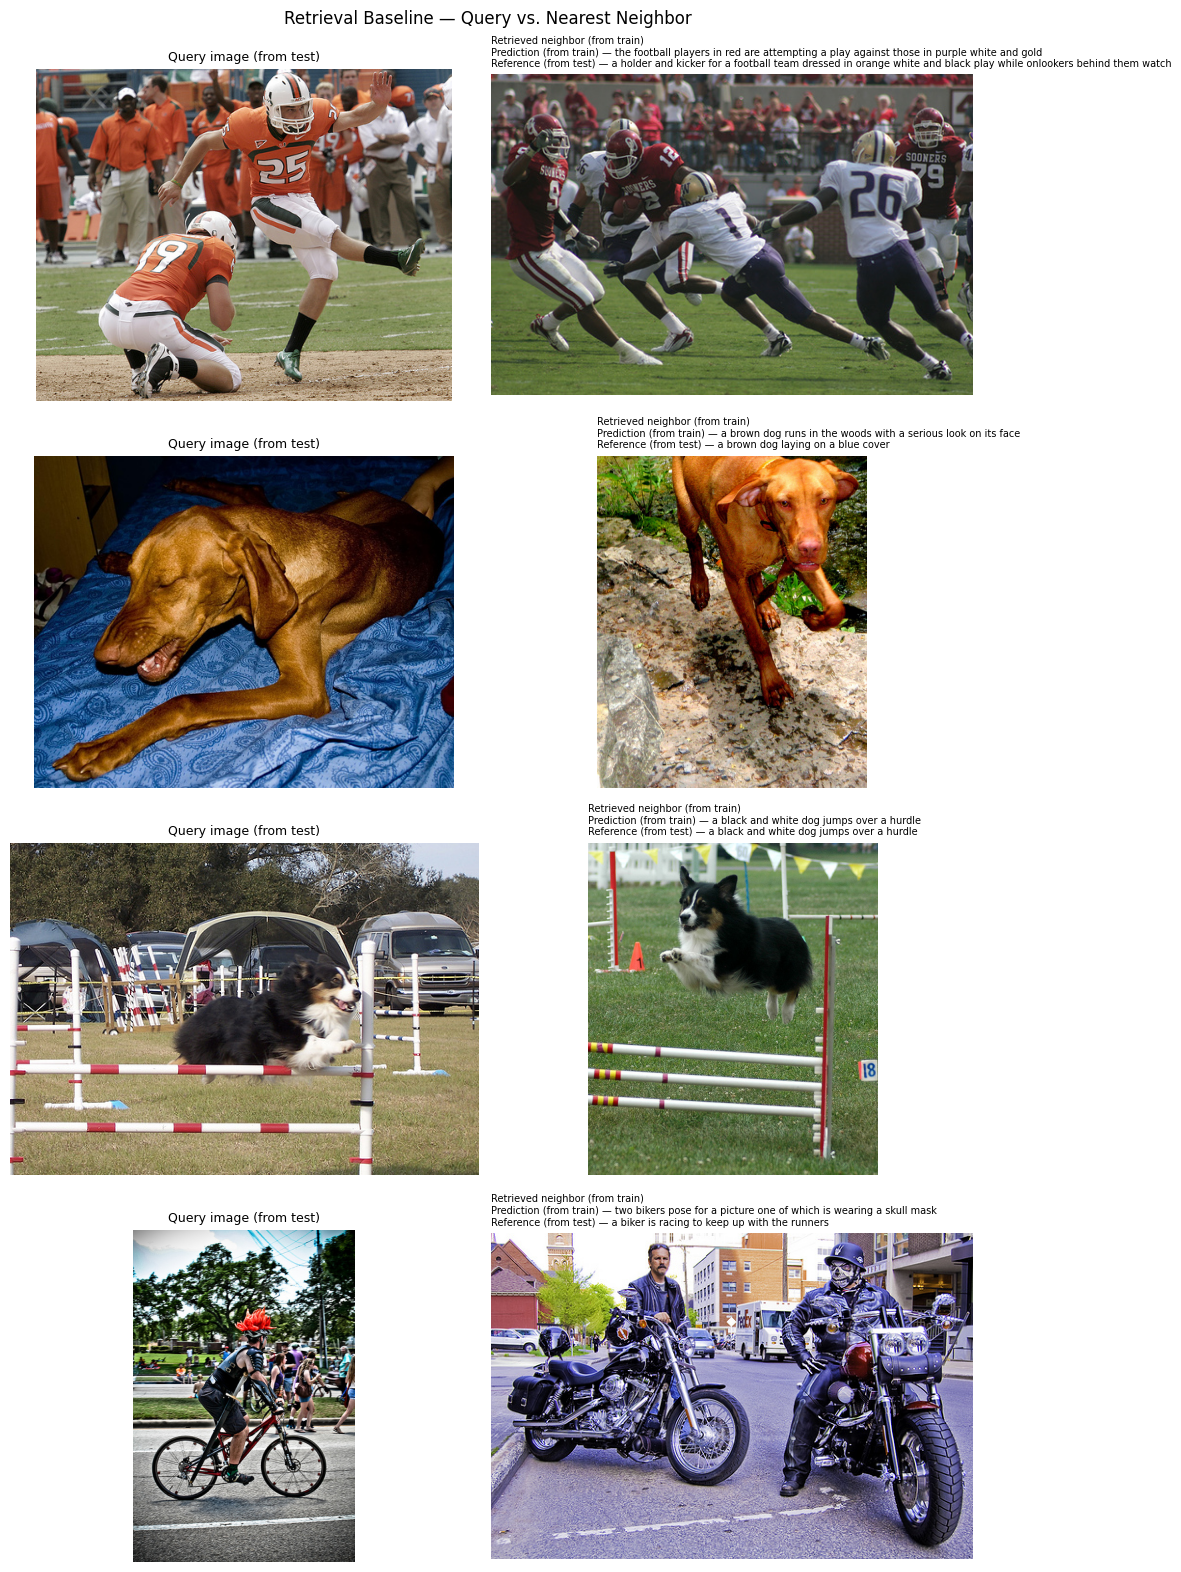

In [17]:
n_show   = 4
sample_i = random.sample(range(len(test_list)), n_show) # get n_show number of randomly sampled indices to extract images to plot

fig, axes = plt.subplots(n_show, 2, figsize = (10, 4 * n_show)) # two cols — 1 test query, 1 training image that model matched

for row, i in enumerate(sample_i):
    # extract file string names
    test_fname     = test_list[i] 
    neighbor_fname = neighbors[i] 
    # joins tokens back together into sentences
    pred_text      = ' '.join(hypotheses[i]) 
    ref_text       = ' '.join(references[i][0])

    # Query image (left column)
    axes[row, 0].imshow(mpimg.imread(os.path.join(IMAGES_DIR, test_fname))) # read and render raw image data from image directory
    axes[row, 0].axis('off') # cleanly present image
    axes[row, 0].set_title('Query image (from test)', fontsize = 9)

    # Retrieved neighbor (right column)
    axes[row, 1].imshow(mpimg.imread(os.path.join(IMAGES_DIR, neighbor_fname)))
    axes[row, 1].axis('off')
    axes[row, 1].set_title(
        f'Retrieved neighbor (from train)\nPrediction (from train) — {pred_text}\nReference (from test) — {ref_text}',
        fontsize = 7,
        loc = 'left'
    )

plt.suptitle('Retrieval Baseline — Query vs. Nearest Neighbor\n', fontsize = 12)
plt.tight_layout()
plt.show()

When the retrieved neighbor is visually similar to the query (e.g., same activity, similar setting), the returned caption is reasonable. When it is not, the caption may be clearly wrong. This demonstrates the fundamental limitation of non-generative retrieval: it cannot compose new language to describe unseen content.

The prediction usually gets the general subject correct (ex. biker but not what kind of biker, football player but not the colors, dog but not the background). 

For example, I ran the code chunk above a few times just to get a feel for the output, and this was the only time there was an exact caption match between the predicted and reference images. This makes sense because BLEU-4 is 7.64%, which indicates that 4-gram sequence matches are infrequent, making exact caption matches rare. 

ResNet-50 features encode high-level visual patterns (ex. object shapes, textures, and scene content). They're good at image classification and capturing broad visual similarity but not as good at capturing precise details, since ResNet-50 compresses each image into just 2,048 numbers. 

And since KNN just finds the nearest neighbor, this results in predictions that will often correctly identify the general subject but not the details. 